In [99]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Machine learning / preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, classification_report,
    roc_curve, auc
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.over_sampling import SMOTE


In [100]:
# 2. Load the Dataset

# Load the employee dataset
employee_df = pd.read_csv('HR_comma_sep.csv')

# Create a copy of the original dataset for analysis
employee_df_copy = employee_df.copy()

# Display the first few records
employee_df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [101]:
# Optional: verify dataset size
print(f"Dataset shape: {employee_df.shape}")

Dataset shape: (14999, 10)


In [102]:
# Inspect column names
print("\nColumn names:")
print(employee_df.columns.tolist())


Column names:
['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'sales', 'salary']


In [103]:
# Inspect data types.
print("\nData types:")
print(employee_df.dtypes)


Data types:
satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
sales                        str
salary                       str
dtype: object


In [104]:
employee_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  str    
 9   salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.3 MB


In [105]:
employee_df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [106]:
# Generate descriptive statistics
print("\nDescriptive statistics for all columns:")
print(employee_df.describe(include="all").T)


Descriptive statistics for all columns:
                         count unique    top  freq        mean        std  \
satisfaction_level     14999.0    NaN    NaN   NaN    0.612834   0.248631   
last_evaluation        14999.0    NaN    NaN   NaN    0.716102   0.171169   
number_project         14999.0    NaN    NaN   NaN    3.803054   1.232592   
average_montly_hours   14999.0    NaN    NaN   NaN  201.050337  49.943099   
time_spend_company     14999.0    NaN    NaN   NaN    3.498233   1.460136   
Work_accident          14999.0    NaN    NaN   NaN     0.14461   0.351719   
left                   14999.0    NaN    NaN   NaN    0.238083   0.425924   
promotion_last_5years  14999.0    NaN    NaN   NaN    0.021268   0.144281   
sales                    14999     10  sales  4140         NaN        NaN   
salary                   14999      3    low  7316         NaN        NaN   

                        min    25%    50%    75%    max  
satisfaction_level     0.09   0.44   0.64   0.82    1

In [107]:
# Inspect unique values of categorical variables
categorical_cols = list(employee_df.select_dtypes(include=["object"]).columns)
for col in categorical_cols:
    print(f"\nUnique values in '{col}':")
    print(employee_df[col].value_counts())



Unique values in 'sales':
sales
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64

Unique values in 'salary':
salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64


In [108]:
print(employee_df["left"].value_counts())

print("\nPercentage distribution:")
print(employee_df["left"].value_counts(normalize=True) * 100)

left
0    11428
1     3571
Name: count, dtype: int64

Percentage distribution:
left
0    76.191746
1    23.808254
Name: proportion, dtype: float64


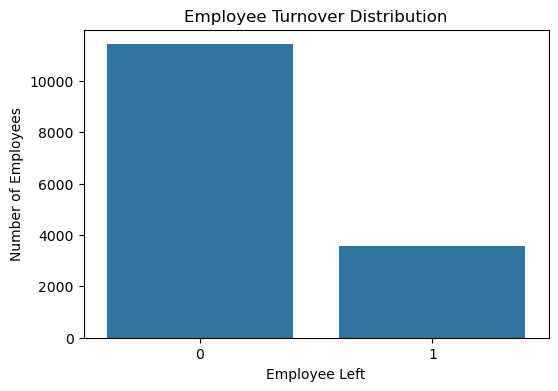

In [109]:
plt.figure(figsize=(6, 4))

sns.countplot(data=employee_df, x="left")

plt.title("Employee Turnover Distribution")
plt.xlabel("Employee Left")
plt.ylabel("Number of Employees")

plt.show()

In [110]:
employee_df.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

In [111]:
employee_df.duplicated().sum()

np.int64(3008)

In [112]:
# Remove exact duplicate records
clean_df = employee_df.drop_duplicates().copy()

print("Original dataset shape:", employee_df.shape)
print("Cleaned dataset shape:", clean_df.shape)
print("Duplicates removed:", employee_df.duplicated().sum())

Original dataset shape: (14999, 10)
Cleaned dataset shape: (11991, 10)
Duplicates removed: 3008


In [113]:
print("Work_accident:", clean_df["Work_accident"].unique())
print("left:", clean_df["left"].unique())
print("promotion_last_5years:", clean_df["promotion_last_5years"].unique())

Work_accident: [0 1]
left: [1 0]
promotion_last_5years: [0 1]


In [114]:
print("Satisfaction range:",
      clean_df["satisfaction_level"].min(),
      clean_df["satisfaction_level"].max())

print("Evaluation range:",
      clean_df["last_evaluation"].min(),
      clean_df["last_evaluation"].max())

print("Projects:",
      sorted(clean_df["number_project"].unique()))

print("Monthly hours:",
      clean_df["average_montly_hours"].min(),
      clean_df["average_montly_hours"].max())

print("Years:",
      sorted(clean_df["time_spend_company"].unique()))

Satisfaction range: 0.09 1.0
Evaluation range: 0.36 1.0
Projects: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Monthly hours: 96 310
Years: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10)]


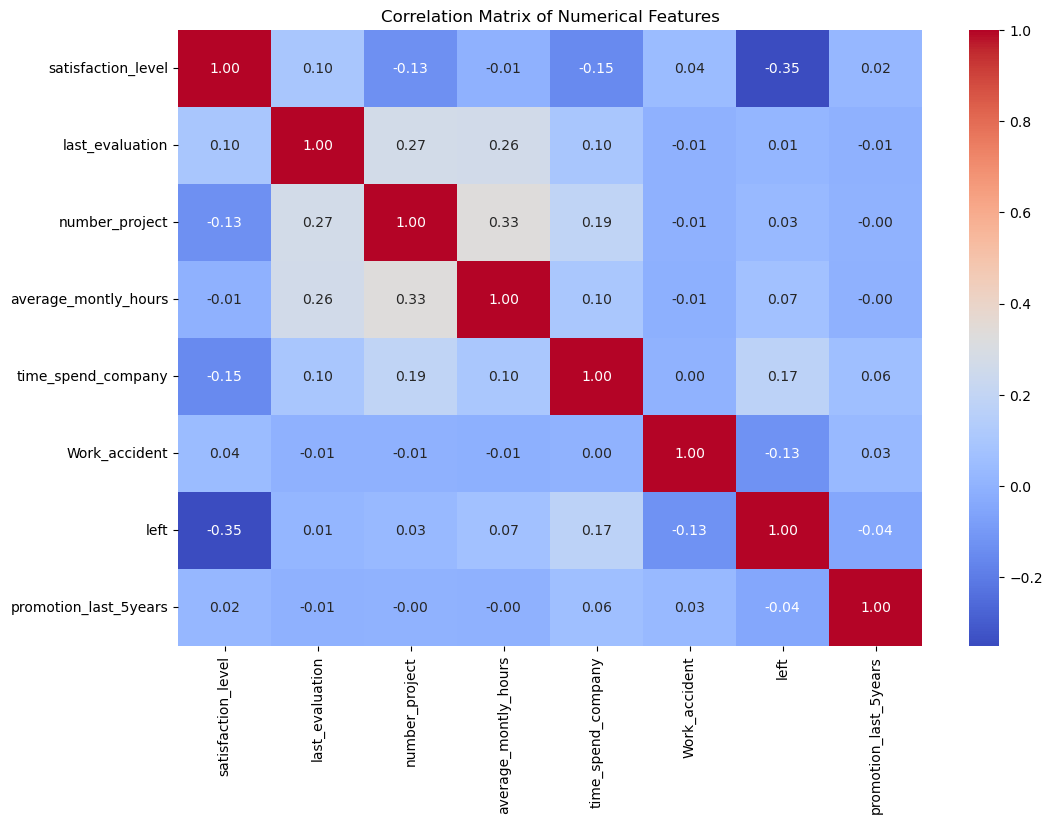

In [115]:
numeric_cols = clean_df.select_dtypes(include=np.number).columns

correlation_matrix = clean_df[numeric_cols].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

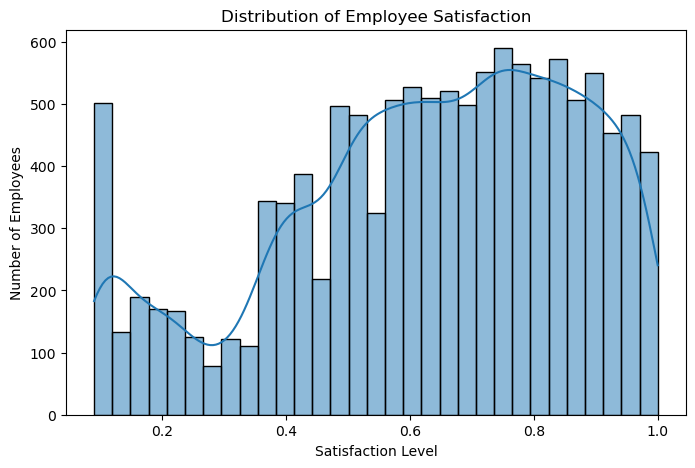

In [116]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=clean_df,
    x="satisfaction_level",
    kde=True
)

plt.title("Distribution of Employee Satisfaction")
plt.xlabel("Satisfaction Level")
plt.ylabel("Number of Employees")

plt.show()

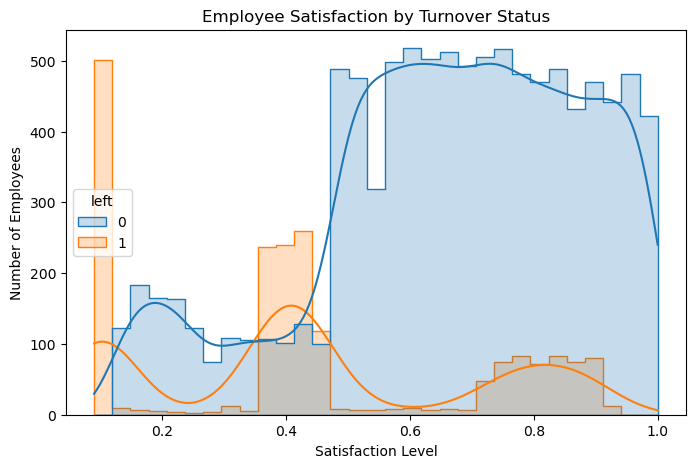

In [117]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=clean_df,
    x="satisfaction_level",
    hue="left",
    kde=True,
    element="step"
)

plt.title("Employee Satisfaction by Turnover Status")
plt.xlabel("Satisfaction Level")
plt.ylabel("Number of Employees")

plt.show()

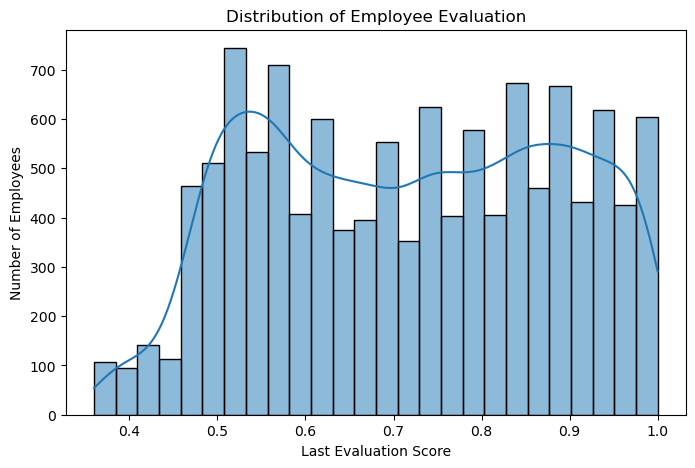

In [118]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=clean_df,
    x="last_evaluation",
    kde=True
)

plt.title("Distribution of Employee Evaluation")
plt.xlabel("Last Evaluation Score")
plt.ylabel("Number of Employees")

plt.show()

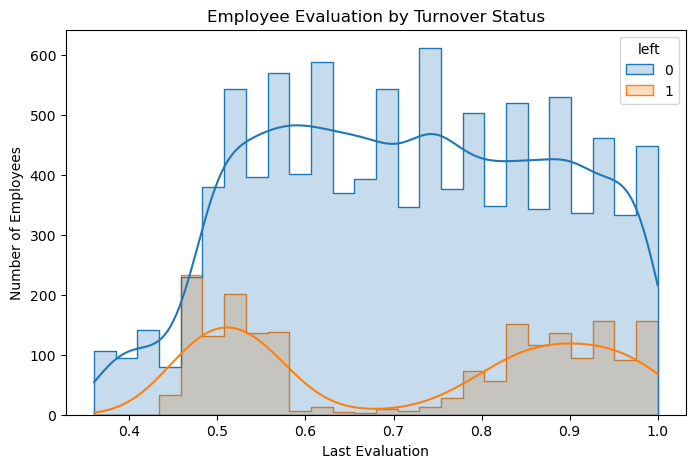

In [119]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=clean_df,
    x="last_evaluation",
    hue="left",
    kde=True,
    element="step"
)

plt.title("Employee Evaluation by Turnover Status")
plt.xlabel("Last Evaluation")
plt.ylabel("Number of Employees")

plt.show()

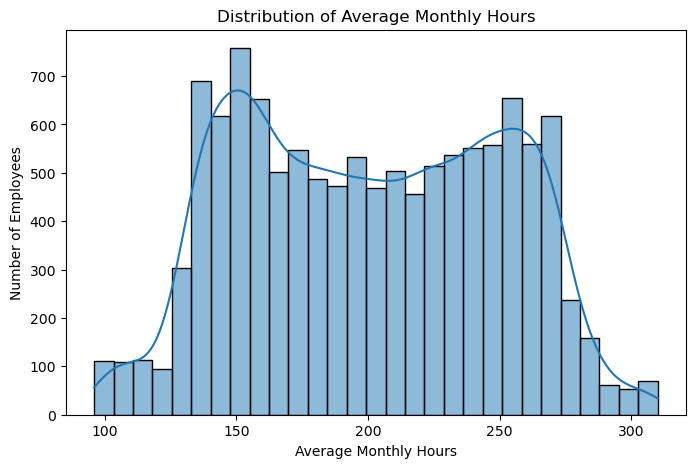

In [120]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=clean_df,
    x="average_montly_hours",
    kde=True
)

plt.title("Distribution of Average Monthly Hours")
plt.xlabel("Average Monthly Hours")
plt.ylabel("Number of Employees")

plt.show()

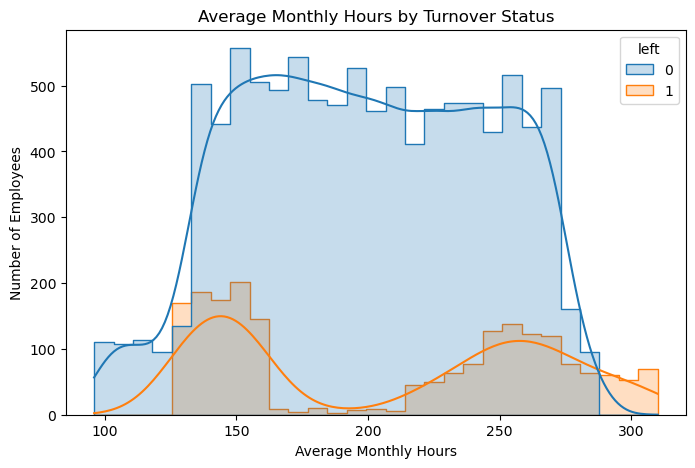

In [121]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=clean_df,
    x="average_montly_hours",
    hue="left",
    kde=True,
    element="step"
)

plt.title("Average Monthly Hours by Turnover Status")
plt.xlabel("Average Monthly Hours")
plt.ylabel("Number of Employees")

plt.show()

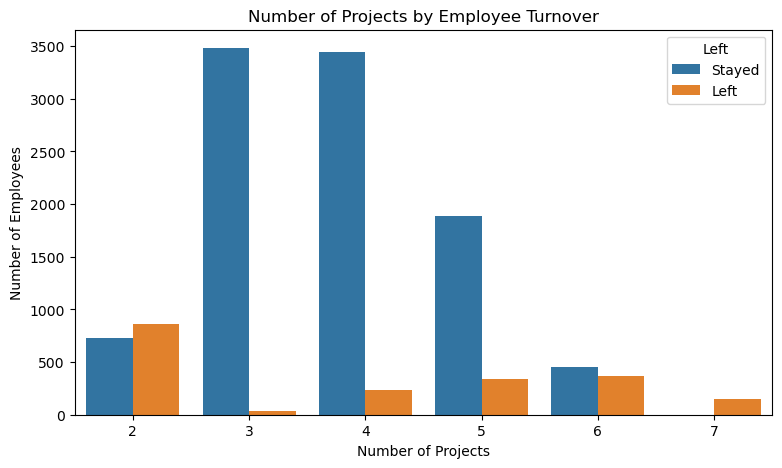

In [122]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=clean_df,
    x="number_project",
    hue="left"
)

plt.title("Number of Projects by Employee Turnover")
plt.xlabel("Number of Projects")
plt.ylabel("Number of Employees")

plt.legend(
    title="Left",
    labels=["Stayed", "Left"]
)

plt.show()

In [123]:
project_turnover = (
    clean_df.groupby("number_project")["left"]
    .agg(["count", "sum", "mean"])
)

project_turnover.columns = [
    "Total Employees",
    "Employees Left",
    "Turnover Rate"
]

project_turnover["Turnover Rate"] *= 100

project_turnover

,Total Employees,Employees Left,Turnover Rate
number_project,,,
2,1582,857,54.171934
3,3520,38,1.079545
4,3685,237,6.431479
5,2233,343,15.360502
6,826,371,44.915254
7,145,145,100.000000


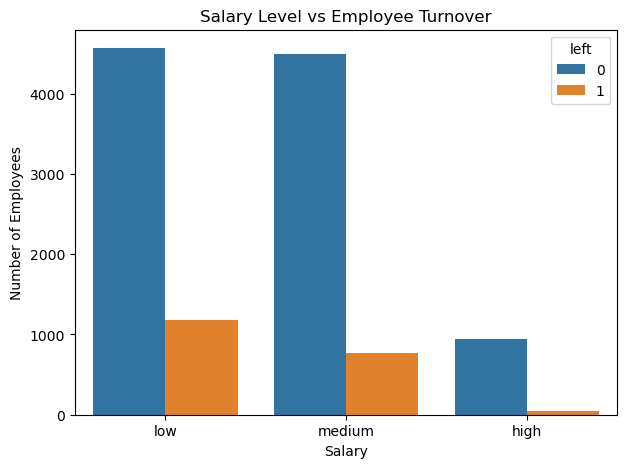

In [124]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=clean_df,
    x="salary",
    hue="left"
)

plt.title("Salary Level vs Employee Turnover")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")

plt.show()

In [125]:
clean_df.groupby("salary")["left"].mean() * 100

salary
high       4.848485
low       20.452962
medium    14.616993
Name: left, dtype: float64

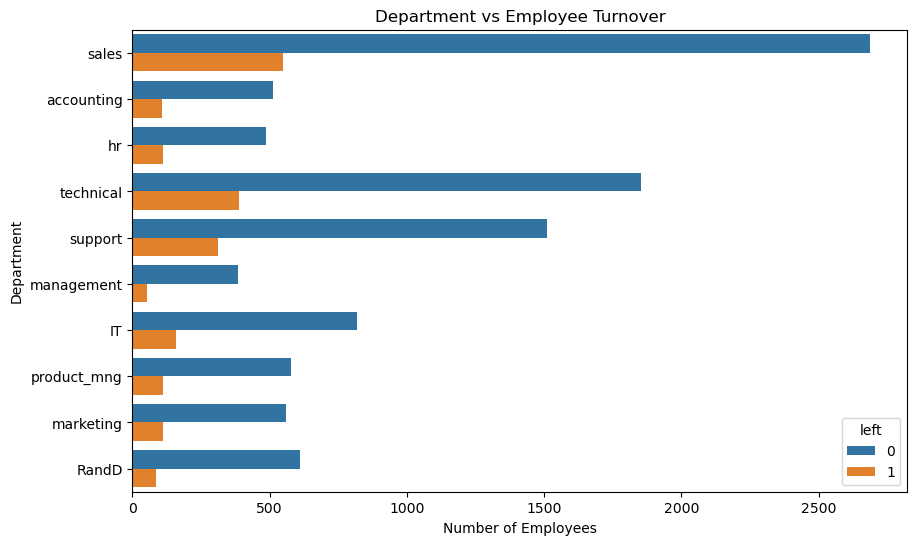

In [126]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=clean_df,
    y="sales",
    hue="left"
)

plt.title("Department vs Employee Turnover")
plt.xlabel("Number of Employees")
plt.ylabel("Department")

plt.show()

In [127]:
clean_df.groupby("sales")["left"].mean().sort_values(ascending=False) * 100

sales
hr             18.801997
accounting     17.552335
technical      17.379679
support        17.133443
sales          16.980550
marketing      16.641902
IT             16.188525
product_mng    16.034985
RandD          12.247839
management     11.926606
Name: left, dtype: float64

In [128]:
pd.crosstab(
    clean_df["promotion_last_5years"],
    clean_df["left"],
    normalize="index"
) * 100

left,0,1
promotion_last_5years,,
0,83.177808,16.822192
1,96.059113,3.940887


In [129]:
pd.crosstab(
    clean_df["Work_accident"],
    clean_df["left"],
    normalize="index"
) * 100

left,0,1
Work_accident,,
0,81.402229,18.597771
1,94.324324,5.675676


In [130]:
left_employees = clean_df[
    clean_df["left"] == 1
][
    ["satisfaction_level", "last_evaluation", "left"]
].copy()

left_employees.head()

,satisfaction_level,last_evaluation,left
0,0.38,0.53,1
1,0.80,0.86,1
2,0.11,0.88,1
3,0.72,0.87,1
4,0.37,0.52,1


In [131]:
cluster_features = left_employees[
    ["satisfaction_level", "last_evaluation"]
]

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(cluster_features)

In [132]:
kmeans = KMeans(
    n_clusters=3,
    random_state=123,
    n_init=10
)

left_employees["Cluster"] = kmeans.fit_predict(cluster_scaled)

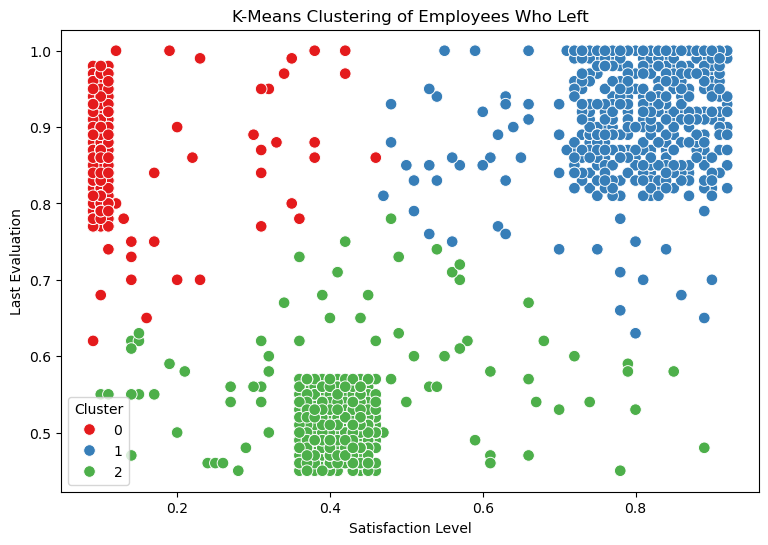

In [133]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=left_employees,
    x="satisfaction_level",
    y="last_evaluation",
    hue="Cluster",
    palette="Set1",
    s=70
)

plt.title("K-Means Clustering of Employees Who Left")
plt.xlabel("Satisfaction Level")
plt.ylabel("Last Evaluation")
plt.legend(title="Cluster")

plt.show()

In [134]:
cluster_summary = (
    left_employees
    .groupby("Cluster")[[
        "satisfaction_level",
        "last_evaluation"
    ]]
    .mean()
)

cluster_summary

,satisfaction_level,last_evaluation
Cluster,,
0,0.111601,0.870923
1,0.803888,0.915298
2,0.410992,0.516483


In [135]:
cluster_summary = (
    left_employees
    .groupby("Cluster")[[
        "satisfaction_level",
        "last_evaluation"
    ]]
    .mean()
    .round(3)
)

cluster_summary

,satisfaction_level,last_evaluation
Cluster,,
0,0.112,0.871
1,0.804,0.915
2,0.411,0.516


In [136]:
cluster_counts = (
    left_employees["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_counts

Cluster
0    531
1    553
2    907
Name: count, dtype: int64

In [137]:
left_employees["Cluster"].value_counts().sort_index()

Cluster
0    531
1    553
2    907
Name: count, dtype: int64

In [138]:
X = clean_df.drop("left", axis=1)
y = clean_df["left"]

In [139]:
categorical_cols = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_cols = X.select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['sales', 'salary']
Numeric columns: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years']


In [140]:
X_categorical = pd.get_dummies(
    X[categorical_cols],
    drop_first=True,
    dtype=int
)

X_numeric = X[numeric_cols]

X_processed = pd.concat(
    [X_numeric, X_categorical],
    axis=1
)

X_processed.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,0,0,0,0,0,0,0,1,0,0,1,0
1,0.80,0.86,5,262,6,0,0,0,0,0,0,0,0,1,0,0,0,1
2,0.11,0.88,7,272,4,0,0,0,0,0,0,0,0,1,0,0,0,1
3,0.72,0.87,5,223,5,0,0,0,0,0,0,0,0,1,0,0,1,0
4,0.37,0.52,2,159,3,0,0,0,0,0,0,0,0,1,0,0,1,0


In [141]:
X_processed.shape

(11991, 18)

In [142]:
X_processed.dtypes

satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
promotion_last_5years      int64
sales_RandD                int64
sales_accounting           int64
sales_hr                   int64
sales_management           int64
sales_marketing            int64
sales_product_mng          int64
sales_sales                int64
sales_support              int64
sales_technical            int64
salary_low                 int64
salary_medium              int64
dtype: object

In [143]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.20,
    random_state=123,
    stratify=y
)

In [144]:
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training shape: (9592, 18)
Testing shape: (2399, 18)

Training target distribution:
left
0    83.39241
1    16.60759
Name: proportion, dtype: float64

Testing target distribution:
left
0    83.409754
1    16.590246
Name: proportion, dtype: float64


In [145]:
from imblearn.pipeline import Pipeline

In [146]:
smote = SMOTE(random_state=123)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [147]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
left
0    7999
1    1593
Name: count, dtype: int64

After SMOTE:
left
0    7999
1    7999
Name: count, dtype: int64


In [148]:
scaler_ml = StandardScaler()

X_train_scaled = scaler_ml.fit_transform(X_train_smote)
X_test_scaled = scaler_ml.transform(X_test)

In [149]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=123
)

In [150]:
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=123)),
    ("model", LogisticRegression(max_iter=1000, random_state=123))
])

logistic_cv_scores = cross_val_score(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("Logistic Regression CV F1 Scores:")
print(logistic_cv_scores)
print("Mean CV F1:", logistic_cv_scores.mean())

Logistic Regression CV F1 Scores:
[0.54954035 0.55780933 0.5329087  0.56170213 0.56399132]
Mean CV F1: 0.5531903667350347


In [151]:
logistic_pipeline.fit(
    X_train_scaled,
    y_train_smote
)

,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,sampling_strategy,'auto'
,random_state,123
,k_neighbors,5
,penalty,'l2'


In [152]:
logistic_pred = logistic_pipeline.predict(X_test_scaled)

In [153]:
print(
    classification_report(
        y_test,
        logistic_pred
    )
)

              precision    recall  f1-score   support

           0       0.91      0.79      0.84      2001
           1       0.37      0.62      0.46       398

    accuracy                           0.76      2399
   macro avg       0.64      0.70      0.65      2399
weighted avg       0.82      0.76      0.78      2399



In [154]:
rf_pipeline = Pipeline([
    ("smote", SMOTE(random_state=123)),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=123,
        n_jobs=-1
    ))
])

rf_cv_scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("Random Forest CV F1 Scores:")
print(rf_cv_scores)
print("Mean CV F1:", rf_cv_scores.mean())

Random Forest CV F1 Scores:
[0.92845787 0.92551506 0.93831169 0.94668821 0.93851133]
Mean CV F1: 0.9354968294119038


In [155]:
rf_pipeline.fit(
    X_train_smote,
    y_train_smote
)

,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,123
,k_neighbors,5
,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2


In [156]:
rf_pred = rf_pipeline.predict(X_test)

In [157]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      2001
           1       0.92      0.91      0.91       398

    accuracy                           0.97      2399
   macro avg       0.95      0.95      0.95      2399
weighted avg       0.97      0.97      0.97      2399



In [158]:
gb_pipeline = Pipeline([
    ("smote", SMOTE(random_state=123)),
    ("model", GradientBoostingClassifier(random_state=123))
])

gb_cv_scores = cross_val_score(
    gb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1"
)

print("Gradient Boosting CV F1 Scores:")
print(gb_cv_scores)
print("Mean CV F1:", gb_cv_scores.mean())

Gradient Boosting CV F1 Scores:
[0.91628615 0.90136571 0.89329268 0.90963855 0.91104294]
Mean CV F1: 0.9063252073412803


In [159]:
gb_pipeline.fit(
    X_train_smote,
    y_train_smote
)

,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,123
,k_neighbors,5
,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0


In [160]:
gb_pred = gb_pipeline.predict(X_test)

In [161]:
print(
    classification_report(
        y_test,
        gb_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      0.97      0.97      2001
           1       0.84      0.92      0.88       398

    accuracy                           0.96      2399
   macro avg       0.91      0.94      0.93      2399
weighted avg       0.96      0.96      0.96      2399



In [162]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "CV F1": [
        logistic_cv_scores.mean(),
        rf_cv_scores.mean(),
        gb_cv_scores.mean()
    ],
    "Accuracy": [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],
    "Precision": [
        precision_score(y_test, logistic_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
    "Recall": [
        recall_score(y_test, logistic_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    "F1": [
        f1_score(y_test, logistic_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, logistic_pipeline.named_steps["model"].predict_proba(X_test_scaled)[:, 1]),
        roc_auc_score(y_test, rf_pipeline.named_steps["model"].predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, gb_pipeline.named_steps["model"].predict_proba(X_test)[:, 1])
    ]
})

model_comparison.sort_values(
    "F1",
    ascending=False
)

,Model,CV F1,Accuracy,Precision,Recall,F1,ROC-AUC
1,Random Forest,0.935497,0.970821,0.916244,0.907035,0.911616,0.973621
2,Gradient Boosting,0.906325,0.958316,0.844907,0.917085,0.879518,0.976342
0,Logistic Regression,0.553190,0.758649,0.366322,0.623116,0.461395,0.784164


In [163]:
logistic_prob = logistic_pipeline.predict_proba(
    X_test_scaled
)[:, 1]

rf_prob = rf_pipeline.predict_proba(
    X_test
)[:, 1]

gb_prob = gb_pipeline.predict_proba(
    X_test
)[:, 1]

In [164]:
logistic_auc = roc_auc_score(y_test, logistic_prob)
rf_auc = roc_auc_score(y_test, rf_prob)
gb_auc = roc_auc_score(y_test, gb_prob)

print("Logistic Regression AUC:", logistic_auc)
print("Random Forest AUC:", rf_auc)
print("Gradient Boosting AUC:", gb_auc)

Logistic Regression AUC: 0.7841644504380976
Random Forest AUC: 0.973621229586212
Gradient Boosting AUC: 0.9763416030678129


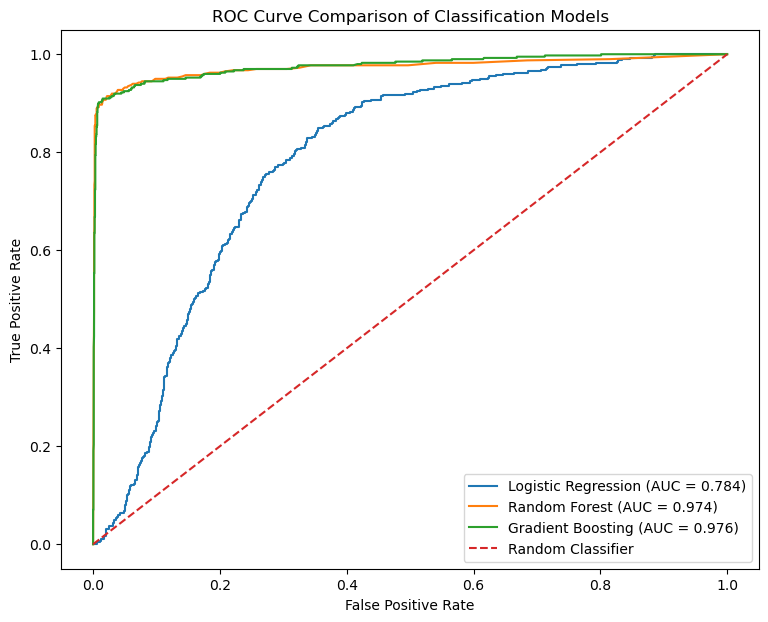

In [165]:
fpr_log, tpr_log, _ = roc_curve(y_test, logistic_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prob)

plt.figure(figsize=(9, 7))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    fpr_gb,
    tpr_gb,
    label=f"Gradient Boosting (AUC = {gb_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Classification Models")
plt.legend()

plt.show()

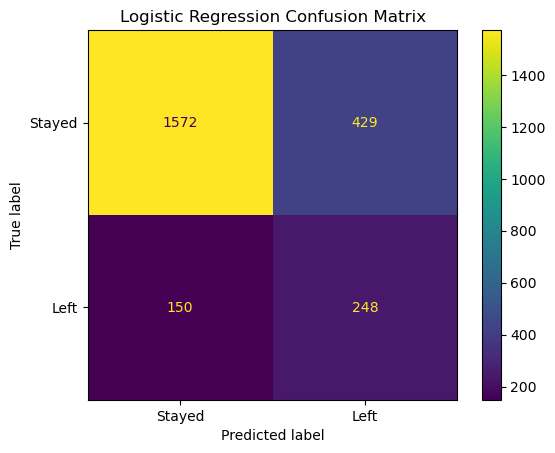

In [166]:
from sklearn.metrics import ConfusionMatrixDisplay
cm_logistic = confusion_matrix(
    y_test,
    logistic_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Stayed", "Left"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

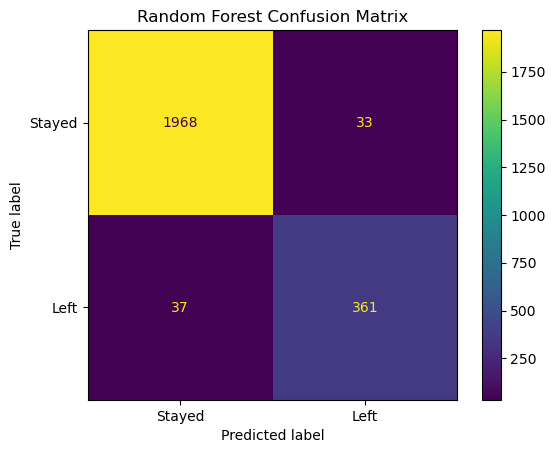

In [167]:
cm_rf = confusion_matrix(
    y_test,
    rf_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Stayed", "Left"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

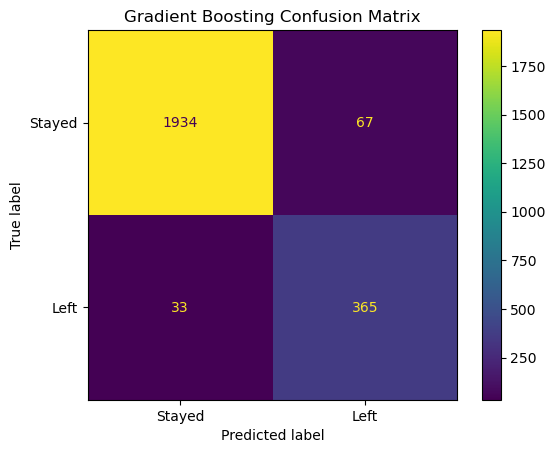

In [168]:
cm_gb = confusion_matrix(
    y_test,
    gb_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_gb,
    display_labels=["Stayed", "Left"]
)

disp.plot()
plt.title("Gradient Boosting Confusion Matrix")
plt.show()

In [169]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "AUC": [
        logistic_auc,
        rf_auc,
        gb_auc
    ],
    "Precision": [
        precision_score(y_test, logistic_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
    "Recall": [
        recall_score(y_test, logistic_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    "F1": [
        f1_score(y_test, logistic_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],
    "Accuracy": [
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ]
})

final_model_comparison.sort_values(
    by="F1",
    ascending=False
)

,Model,AUC,Precision,Recall,F1,Accuracy
1,Random Forest,0.973621,0.916244,0.907035,0.911616,0.970821
2,Gradient Boosting,0.976342,0.844907,0.917085,0.879518,0.958316
0,Logistic Regression,0.784164,0.366322,0.623116,0.461395,0.758649


In [170]:
best_model_name = final_model_comparison.loc[
    final_model_comparison["F1"].idxmax(),
    "Model"
]

print("Best model based on Test F1:", best_model_name)

Best model based on Test F1: Random Forest


In [171]:
if best_model_name == "Logistic Regression":
    best_model = logistic_pipeline
    best_probabilities = logistic_prob

elif best_model_name == "Random Forest":
    best_model = rf_pipeline
    best_probabilities = rf_prob

else:
    best_model = gb_pipeline
    best_probabilities = gb_prob

In [172]:
def assign_risk_zone(probability):
    if probability < 0.20:
        return "Safe Zone (Green)"
    elif probability < 0.60:
        return "Low-Risk Zone (Yellow)"
    elif probability < 0.90:
        return "Medium-Risk Zone (Orange)"
    else:
        return "High-Risk Zone (Red)"

In [173]:
risk_df = clean_df.loc[X_test.index].copy()

risk_df["turnover_probability"] = best_probabilities
risk_df["risk_zone"] = risk_df["turnover_probability"].apply(
    assign_risk_zone
)

risk_df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary,turnover_probability,risk_zone
8578,0.82,0.95,6,191,6,0,0,0,accounting,medium,0.130,Safe Zone (Green)
5756,0.18,0.86,5,267,4,0,0,0,accounting,medium,0.265,Low-Risk Zone (Yellow)
3994,0.63,0.98,4,160,2,0,0,0,sales,medium,0.030,Safe Zone (Green)
1784,0.43,0.51,2,149,3,1,1,0,accounting,medium,0.905,High-Risk Zone (Red)
10508,0.51,0.98,4,245,3,0,0,0,support,medium,0.010,Safe Zone (Green)


In [174]:
risk_df = risk_df.sort_values(
    "turnover_probability",
    ascending=False
)

In [175]:
risk_df["risk_zone"] = (
    risk_df["turnover_probability"]
    .apply(assign_risk_zone)
)

In [176]:
risk_df["risk_zone"].value_counts()

risk_zone
Safe Zone (Green)            1838
High-Risk Zone (Red)          330
Low-Risk Zone (Yellow)        185
Medium-Risk Zone (Orange)      46
Name: count, dtype: int64

In [177]:
risk_summary = (
    risk_df
    .groupby("risk_zone")
    .agg(
        Employee_Count=("risk_zone", "size"),
        Average_Turnover_Probability=("turnover_probability", "mean"),
        Actual_Turnover_Rate=("left", "mean")
    )
)

risk_summary["Average_Turnover_Probability"] *= 100
risk_summary["Actual_Turnover_Rate"] *= 100

risk_summary

,Employee_Count,Average_Turnover_Probability,Actual_Turnover_Rate
risk_zone,,,
High-Risk Zone (Red),330,98.457576,98.484848
Low-Risk Zone (Yellow),185,32.224324,10.270270
Medium-Risk Zone (Orange),46,79.336957,69.565217
Safe Zone (Green),1838,3.677639,1.196953


In [178]:
high_risk_employees = risk_df[
    risk_df["risk_zone"] == "High-Risk Zone (Red)"
].copy()

high_risk_employees.head(20)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary,turnover_probability,risk_zone
1245,0.10,0.93,6,288,4,0,1,0,sales,medium,1.0,High-Risk Zone (Red)
1233,0.41,0.54,2,152,3,0,1,0,sales,medium,1.0,High-Risk Zone (Red)
917,0.38,0.55,2,145,3,0,1,0,support,low,1.0,High-Risk Zone (Red)
502,0.11,0.87,7,282,5,0,1,0,technical,low,1.0,High-Risk Zone (Red)
801,0.43,0.55,2,153,3,0,1,0,technical,medium,1.0,High-Risk Zone (Red)
446,0.44,0.46,2,143,3,0,1,0,IT,low,1.0,High-Risk Zone (Red)
1889,0.11,0.95,6,279,4,0,1,0,technical,low,1.0,High-Risk Zone (Red)
1955,0.09,0.81,6,257,4,0,1,0,support,low,1.0,High-Risk Zone (Red)
344,0.37,0.52,2,155,3,0,1,0,technical,medium,1.0,High-Risk Zone (Red)
223,0.87,0.90,5,252,5,0,1,0,IT,low,1.0,High-Risk Zone (Red)


In [179]:
high_risk_employees[
    [
        "satisfaction_level",
        "last_evaluation",
        "number_project",
        "average_montly_hours",
        "time_spend_company",
        "promotion_last_5years",
        "sales",
        "salary",
        "turnover_probability",
        "risk_zone"
    ]
].head(20)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,promotion_last_5years,sales,salary,turnover_probability,risk_zone
1245,0.10,0.93,6,288,4,0,sales,medium,1.0,High-Risk Zone (Red)
1233,0.41,0.54,2,152,3,0,sales,medium,1.0,High-Risk Zone (Red)
917,0.38,0.55,2,145,3,0,support,low,1.0,High-Risk Zone (Red)
502,0.11,0.87,7,282,5,0,technical,low,1.0,High-Risk Zone (Red)
801,0.43,0.55,2,153,3,0,technical,medium,1.0,High-Risk Zone (Red)
446,0.44,0.46,2,143,3,0,IT,low,1.0,High-Risk Zone (Red)
1889,0.11,0.95,6,279,4,0,technical,low,1.0,High-Risk Zone (Red)
1955,0.09,0.81,6,257,4,0,support,low,1.0,High-Risk Zone (Red)
344,0.37,0.52,2,155,3,0,technical,medium,1.0,High-Risk Zone (Red)
223,0.87,0.90,5,252,5,0,IT,low,1.0,High-Risk Zone (Red)


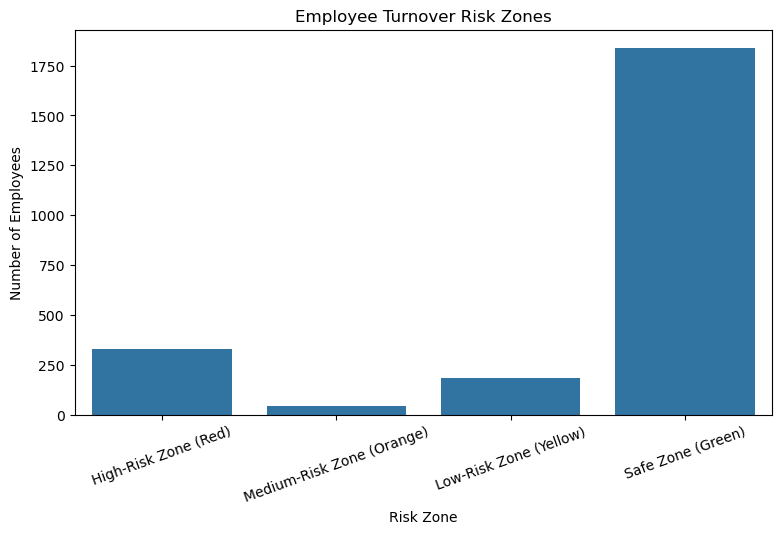

In [180]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=risk_df,
    x="risk_zone"
)

plt.title("Employee Turnover Risk Zones")
plt.xlabel("Risk Zone")
plt.ylabel("Number of Employees")

plt.xticks(rotation=20)

plt.show()

# Employee Retention Strategies

## 1. Safe Zone — Green (<20%)

These employees have a relatively low predicted probability of leaving.

### Recommended actions

* Continue regular employee engagement activities.
* Recognize and reward strong performance.
* Maintain competitive compensation and benefits.
* Provide ongoing learning and career-development opportunities.
* Continue periodic satisfaction monitoring.

The objective is to maintain the factors contributing to employee retention rather than applying intensive intervention.

## 2. Low-Risk Zone — Yellow (20–60%)

These employees show early signs of potential turnover risk.

### Recommended actions

* Conduct periodic one-on-one discussions.
* Monitor employee satisfaction.
* Discuss career goals and development opportunities.
* Review workload and project allocation.
* Identify potential concerns with management, compensation, or career progression.

The objective is early intervention before the employee becomes a higher-risk case.

## 3. Medium-Risk Zone — Orange (60–90%)

These employees have a substantial predicted probability of turnover.

### Recommended actions

* Conduct targeted retention discussions.
* Review workload and number of projects.
* Investigate satisfaction-related concerns.
* Discuss career progression and promotion opportunities.
* Review compensation where appropriate.
* Consider training, role adjustments, or project reassignment.
* Develop an individualized retention plan.

These employees should receive higher priority from HR.

## 4. High-Risk Zone — Red (>90%)

These employees have a very high predicted probability of leaving.

### Recommended actions

* Prioritize immediate HR intervention.
* Conduct a confidential retention interview.
* Identify the primary reason for potential departure.
* Review compensation and promotion opportunities.
* Assess workload and project pressure.
* Explore alternative roles or career-development opportunities where appropriate.
* Develop a personalized retention plan.

The objective is to identify actionable reasons for potential departure and intervene before turnover occurs.
